
# PROYECTO DATAXPIRIENCE
t
## Análisis de datos de computadores portátiles con Python y pandas

| | |
|---|---|
| **Autores** | Cristian Pico & Daniela Castro |
| **Fuente de datos** | Dataset sintético generado para el proyecto |

---

**Resumen del proyecto**

Se analiza un conjunto de datos de **228 registros** de computadores portátiles
(marca, procesador, memoria RAM, almacenamiento, tarjeta gráfica, pantalla,
batería, conectividad, software y precio). El trabajo se desarrolla en **3 módulos**:

1. **Módulo 1 – Fundamentos y preparación de datos:** exploración, limpieza y transformación.
2. **Módulo 2 – Análisis estadístico:** medidas de tendencia central, dispersión, outliers e hipótesis.
3. **Módulo 3 – Visualización y modelo predictivo:** gráficos, storytelling y regresión lineal para estimar el precio.

**Justificación:** los computadores portátiles son uno de los productos con mayor
rotación en tiendas de tecnología. Poder *medir* qué características explican el
precio permite apoyar la toma de decisiones comerciales (cotización, descuentos,
inventario y asesoría al cliente), que es un campo directamente relacionado con la
carrera del autor.


## 0. Dataset – selección y generación de los datos


La primera etapa del curso pide *seleccionar, explorar y preparar* un conjunto de
datos. Elegí trabajar con **portátiles**, porque es un dominio cercano a la venta de
tecnología: entender qué componentes encarecen un equipo (y en cuánto) es una
habilidad clave para asesorar compradores y fijar precios.




In [6]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Reemplaza '/content/drive/MyDrive/RUTA_AQUI/computadores_portatiles.csv' con la ruta real de tu archivo en Google Drive
df = pd.read_csv('/computadores_portatiles.csv')
df.head(3)

ModuleNotFoundError: No module named 'pandas'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



### Variables del dataset

| Bloque | Variables |
|---|---|
| Identificación | `id`, `marca`, `modelo`, `tipo_computador` |
| Procesador | `procesador_marca`, `procesador_modelo`, `generacion_cpu`, `nucleos_cpu`, `hilos_cpu`, `frecuencia_base_ghz`, `frecuencia_max_ghz` |
| RAM | `ram_gb`, `tipo_ram`, `velocidad_ram_mhz` |
| Almacenamiento | `almacenamiento_gb`, `tipo_almacenamiento`, `almacenamiento_secundario_gb` |
| Gráfica | `gpu_marca`, `gpu_modelo`, `tipo_gpu`, `vram_gb` |
| Pantalla | `tamano_pantalla`, `resolucion_ancho`, `resolucion_alto`, `tipo_panel`, `tasa_refresco_hz`, `pantalla_tactil` |
| Física | `bateria_wh`, `peso_kg`, `ancho_cm`, `profundidad_cm`, `grosor_cm` |
| Conectividad | `wifi`, `bluetooth`, `puertos_usb`, `puerto_hdmi`, `puerto_ethernet` |
| Software | `sistema_operativo`, `version_so`, `garantia_meses` |
| Económicas | `precio`, `precio_anterior`, `descuento_porcentaje`, `precio_usd` |



---

## Módulo 1 – Fundamentos y preparación de datos

**Objetivo:** seleccionar, explorar y preparar un conjunto de datos relevante.
**Lecciones aplicadas:** identificación de tipos de variables, problemas de calidad
(nulos, duplicados, codificaciones inadecuadas y outliers) y transformaciones.


### 1.1 Exploración inicial

In [ ]:
print("Forma del dataset (filas, columnas):", df.shape)
print("Cantidad de columnas por tipo:\n")
print(df.dtypes.value_counts().to_string())

Forma del dataset (filas, columnas): (228, 44)
Cantidad de columnas por tipo:

int64      18
object     14
float64    12


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 44 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            228 non-null    int64  
 1   marca                         228 non-null    object 
 2   modelo                        228 non-null    object 
 3   tipo_computador               228 non-null    object 
 4   procesador_marca              228 non-null    object 
 5   procesador_modelo             228 non-null    object 
 6   generacion_cpu                228 non-null    int64  
 7   nucleos_cpu                   225 non-null    float64
 8   hilos_cpu                     228 non-null    int64  
 9   frecuencia_base_ghz           228 non-null    float64
 10  frecuencia_max_ghz            228 non-null    float64
 11  ram_gb                        228 non-null    int64  
 12  tipo_ram                      228 non-null    object 
 13  veloc

### 1.2 Detección de problemas de calidad

In [ ]:
print("== Valores nulos por columna ==")
print(df.isna().sum()[df.isna().sum() > 0])
print("\n== Filas completamente duplicadas ==")
print("Duplicados:", df.duplicated().sum())

== Valores nulos por columna ==
nucleos_cpu           3
tipo_panel            7
bateria_wh           13
sistema_operativo     5
version_so           10
dtype: int64

== Filas completamente duplicadas ==
Duplicados: 8


In [ ]:
print("== Codificaciones de texto inconsistentes ==")
for col in ["marca", "tipo_computador", "tipo_almacenamiento", "sistema_operativo",
            "wifi", "tipo_ram", "gpu_marca", "bluetooth"]:
    print(f"\n[{col}] valores únicos:")
    print(df[col].astype(str).unique()[:15])

== Codificaciones de texto inconsistentes ==

[marca] valores únicos:
['Samsung' 'Apple' 'Xiaomi' 'MSI' 'Lenovo' 'Acer' 'Dell' 'Asus' 'lenovo'
 'LG' 'HP' 'HP ' '  Asus']

[tipo_computador] valores únicos:
['Notebook' 'Ultrabook' 'Gaming' 'Workstation' '2 en 1' 'Profesional'
 'Gaming ']

[tipo_almacenamiento] valores únicos:
['HDD' 'SSD' ' ssd ' 'SSD+HDD' 'ssd' 'SSD + HDD']

[sistema_operativo] valores únicos:
['Windows 11' 'macOS' 'windows 11 pro' 'FreeDOS' 'nan']

[wifi] valores únicos:
['WiFi 6E' 'WiFi 6' 'WiFi 5' 'WiFi 7' 'wifi6']

[tipo_ram] valores únicos:
['DDR5' 'LPDDR5' 'DDR4' 'LPDDR4X' 'ddr4']

[gpu_marca] valores únicos:
['Intel' 'Apple' 'NVIDIA' 'AMD' 'nvidia']

[bluetooth] valores únicos:
['5.1' '5.0' '5.2' '5.3' '4.2']


In [ ]:
print("== Distribución general (posibles outliers) ==")
df.describe().T.round(2)

== Distribución general (posibles outliers) ==


,count,mean,std,min,25%,50%,75%,max
id,228.0,1108.33,63.47,1000.00,1053.75,1107.50,1162.25,1219.00
generacion_cpu,228.0,11.77,2.59,1.00,11.00,12.00,13.00,14.00
nucleos_cpu,225.0,7.90,2.77,3.00,6.00,8.00,8.00,17.00
hilos_cpu,228.0,14.14,4.38,0.00,12.00,14.00,16.00,26.00
frecuencia_base_ghz,228.0,2.45,0.27,1.90,2.26,2.41,2.58,3.34
frecuencia_max_ghz,228.0,4.67,0.42,3.18,4.41,4.72,4.98,5.63
ram_gb,228.0,31.54,134.94,8.00,14.00,16.00,32.00,2048.00
velocidad_ram_mhz,228.0,4408.03,1103.76,2666.00,3200.00,4800.00,5200.00,6400.00
almacenamiento_gb,228.0,895.54,604.04,256.00,512.00,512.00,1024.00,2048.00
almacenamiento_secundario_gb,228.0,206.14,466.08,0.00,0.00,0.00,0.00,2000.00



**Problemas detectados en la exploración:**

- **Valores nulos** en `bateria_wh` (13), `tipo_panel` (7), `sistema_operativo` (5),
  `version_so` (10) y `nucleos_cpu` (3). En un caso real serían equipos con
  especificación desconocida por omisión del vendedor o ficha incompleta.
- **8 filas duplicadas**: mismos equipos cargados dos veces (error típico de
  exportar/concat en la base de datos del inventario).
- **Texto inconsistente**: `"HP "` con espacio, `"lenovo"` en minúscula, `"Gaming "`
  con espacio final, `"ssd"` y `"SSD + HDD"` sin normalizar, `"wifi6"`, `"ddr4"`,
  `"nvidia"` en minúsculas. Si no se estandarizan, cada variante se cuenta como una
  categoría distinta y rompe análisis de agrupación.
- **Outliers extremos/imposibles**: precios de `98.000.000` y `75.000.000` COP,
  un peso de `88.5 kg`, `620 Wh` de batería, una pantalla de `3.5"`, `2048 GB`
  de RAM y `0` hilos de CPU → valores sin sentido físico.


### 1.3 Limpieza: nulos y duplicados

In [ ]:
# 1) Eliminar filas duplicadas exactas
antes = len(df)
df = df.drop_duplicates().copy()
print(f"Duplicados eliminados: {antes - len(df)} -> quedan {len(df)} filas")

# 2) Tratar nulos con criterio
df["bateria_wh"] = df["bateria_wh"].fillna(df["bateria_wh"].median())
df["nucleos_cpu"] = df["nucleos_cpu"].fillna(df["nucleos_cpu"].median())
df["tipo_panel"] = df["tipo_panel"].fillna(df["tipo_panel"].mode()[0])
df["sistema_operativo"] = df["sistema_operativo"].fillna("Windows 11")
df["version_so"] = df["version_so"].fillna("No aplica")

print("Restan nulos por columna:")
print(df.isna().sum()[df.isna().sum() > 0])

Duplicados eliminados: 8 -> quedan 220 filas
Restan nulos por columna:
Series([], dtype: int64)


### 1.4 Limpieza: estandarización de texto

In [ ]:
# Normalizar mayúsculas y espacios, y unificar sinónimos
df["marca"] = df["marca"].str.strip().str.title().replace({"Hp": "HP"})
df["tipo_computador"] = df["tipo_computador"].str.strip()
df["tipo_almacenamiento"] = (
    df["tipo_almacenamiento"].str.strip().str.upper().str.replace(" ", "")
)
df["sistema_operativo"] = (
    df["sistema_operativo"]
    .str.strip().str.title()
    .replace({"Macos": "macOS", "Freedos": "FreeDOS"})
)
df["wifi"] = df["wifi"].str.strip().str.replace("wifi6", "WiFi 6", case=False)
df["tipo_ram"] = df["tipo_ram"].str.strip().str.upper()
df["gpu_marca"] = df["gpu_marca"].str.strip().str.title().replace({"Amd": "AMD", "Nvidia": "NVIDIA"})
df["bluetooth"] = df["bluetooth"].astype(str)

marca_bien = df["marca"].unique().tolist()
print("Marcas normalizadas:", sorted(marca_bien))
print("Tipo almacenamiento:", df["tipo_almacenamiento"].unique())
print("Sistemas operativos:", df["sistema_operativo"].unique())

Marcas normalizadas: ['Acer', 'Apple', 'Asus', 'Dell', 'HP', 'Lenovo', 'Lg', 'Msi', 'Samsung', 'Xiaomi']
Tipo almacenamiento: ['HDD' 'SSD' 'SSD+HDD']
Sistemas operativos: ['Windows 11' 'macOS' 'Windows 11 Pro' 'FreeDOS']


### 1.5 Corrección de tipos de datos

In [ ]:
columnas_numericas = [
    "id", "generacion_cpu", "nucleos_cpu", "hilos_cpu", "frecuencia_base_ghz",
    "frecuencia_max_ghz", "ram_gb", "velocidad_ram_mhz", "almacenamiento_gb",
    "almacenamiento_secundario_gb", "vram_gb", "tamano_pantalla", "resolucion_ancho",
    "resolucion_alto", "tasa_refresco_hz", "pantalla_tactil", "bateria_wh", "peso_kg",
    "ancho_cm", "profundidad_cm", "grosor_cm", "puertos_usb", "puerto_hdmi",
    "puerto_ethernet", "garantia_meses", "precio", "precio_anterior",
    "descuento_porcentaje", "precio_usd",
]
for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.dtypes.value_counts().to_string())

int64      18
object     15
float64    11


### 1.6 Tratamiento de outliers imposibles

In [ ]:
print("Valores extremos detectados:")
print("- Precio máximo:", f"{df['precio'].max():,.0f}", "COP")
print("- Peso máximo:", df["peso_kg"].max(), "kg")
print("- RAM máxima:", df["ram_gb"].max(), "GB")
print("- Batería máx.:", df["bateria_wh"].max(), "Wh")
print("- Pantalla mín.:", df["tamano_pantalla"].min(), 'pulgadas')
print("- Hilos mínimos:", df["hilos_cpu"].min())

cond_filtro = (
    (df["precio"] < 60_000_000) & (df["precio"] > 900_000)
    & (df["peso_kg"] < 20) & (df["ram_gb"] <= 128)
    & (df["tamano_pantalla"] >= 10) & (df["hilos_cpu"] > 0)
)
antes = len(df)
df = df.loc[cond_filtro].reset_index(drop=True)
print(f"\nFilas eliminadas por ser registros imposibles: {antes - len(df)}")
print(f"Dataset operativo: {len(df)} filas")

Valores extremos detectados:
- Precio máximo: 98,000,000 COP
- Peso máximo: 88.5 kg
- RAM máxima: 2048 GB
- Batería máx.: 620.0 Wh
- Pantalla mín.: 3.5 pulgadas
- Hilos mínimos: 0

Filas eliminadas por ser registros imposibles: 7
Dataset operativo: 213 filas


### 1.7 Transformaciones: variables derivadas

In [ ]:
# Densidad de píxeles (píxeles por pulgada²) - cuánta nitidez ofrece la pantalla
df["densidad_pixeles"] = (df["resolucion_ancho"] * df["resolucion_alto"]) / (df["tamano_pantalla"] ** 2)

# Capacidad total de almacenamiento (SSD + HDD cuando aplica)
df["capacidad_total_almacenamiento"] = df["almacenamiento_gb"] + df["almacenamiento_secundario_gb"]

nuevas = ["densidad_pixeles", "capacidad_total_almacenamiento"]
df[nuevas].describe().round(1)

,densidad_pixeles,capacidad_total_almacenamiento
count,213.0,213.0
mean,14523.4,1086.0
std,7824.0,776.1
min,3505.3,256.0
25%,8520.7,512.0
50%,11722.5,1024.0
75%,16831.0,1512.0
max,37869.8,4048.0


### 1.8 Resumen del dataset depurado

In [ ]:
df.to_csv("computadores_limpio.csv", index=False)
print("≈ Dataset final:", df.shape[0], "filas x", df.shape[1], "columnas")
print("≈ Sin nulos:", df.isna().sum().sum() == 0)
print("≈ Sin duplicados:", df.duplicated().sum() == 0)
df.head(3)

≈ Dataset final: 213 filas x 46 columnas
≈ Sin nulos: True
≈ Sin duplicados: True


,id,marca,modelo,tipo_computador,procesador_marca,procesador_modelo,generacion_cpu,nucleos_cpu,hilos_cpu,frecuencia_base_ghz,frecuencia_max_ghz,ram_gb,tipo_ram,velocidad_ram_mhz,almacenamiento_gb,tipo_almacenamiento,almacenamiento_secundario_gb,gpu_marca,gpu_modelo,tipo_gpu,vram_gb,tamano_pantalla,resolucion_ancho,resolucion_alto,tipo_panel,tasa_refresco_hz,pantalla_tactil,bateria_wh,peso_kg,ancho_cm,profundidad_cm,grosor_cm,wifi,bluetooth,puertos_usb,puerto_hdmi,puerto_ethernet,sistema_operativo,version_so,garantia_meses,precio,precio_anterior,descuento_porcentaje,precio_usd,densidad_pixeles,capacidad_total_almacenamiento
0,1000,Samsung,Samsung 2486,Notebook,Intel,Core i3,12,4.0,8,3.03,4.48,8,DDR5,4800,2000,HDD,0,Intel,Iris Xe Graphics,Integrada,0,17.3,1920,1080,TN,60,0,44.6,2.09,39.2,27.5,1.85,WiFi 6E,5.1,3,1,0,Windows 11,Home,24,4133019,4862375,15.0,1033.25,6928.397207,2000
1,1001,Apple,Apple 3041,Ultrabook,Apple,M1,1,8.0,8,2.17,3.31,16,LPDDR5,6400,1024,SSD,0,Apple,GPU Apple,Integrada,0,13.3,2560,1600,IPS,60,0,59.3,1.13,30.5,21.7,1.91,WiFi 6E,5.0,2,1,1,macOS,Ventura,6,6565559,6911115,5.0,1641.39,23155.633445,1024
2,1002,Xiaomi,Xiaomi 6889,Gaming,Intel,Core i5,13,6.0,12,2.23,4.55,32,DDR4,3200,2048,SSD,1000,NVIDIA,RTX 3050,Dedicada,6,15.6,1920,1080,OLED,240,0,81.7,2.37,35.9,23.0,1.84,WiFi 6,5.2,3,1,1,Windows 11,Home,12,10979884,10979884,0.0,2744.97,8520.710059,3048


In [ ]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
id,213.0,1106.05,61.72,1000.00,1053.00,1106.00,1159.00,1219.00
generacion_cpu,213.0,11.70,2.65,1.00,11.00,12.00,13.00,14.00
nucleos_cpu,213.0,7.83,2.74,3.00,6.00,8.00,8.00,17.00
hilos_cpu,213.0,14.06,4.26,8.00,12.00,14.00,16.00,26.00
frecuencia_base_ghz,213.0,2.46,0.27,1.90,2.26,2.42,2.60,3.34
frecuencia_max_ghz,213.0,4.66,0.43,3.18,4.39,4.71,4.98,5.63
ram_gb,213.0,22.27,14.58,8.00,8.00,16.00,32.00,64.00
velocidad_ram_mhz,213.0,4402.97,1113.11,2666.00,3200.00,4800.00,5200.00,6400.00
almacenamiento_gb,213.0,884.09,598.72,256.00,512.00,512.00,1024.00,2048.00
almacenamiento_secundario_gb,213.0,201.88,467.43,0.00,0.00,0.00,0.00,2000.00



---

## Módulo 2 – Análisis estadístico

**Objetivo:** aplicar medidas estadísticas descriptivas para comprender el
comportamiento de los datos: tendencia central, dispersión, comparaciones,
outliers y relaciones entre variables.


### 2.1 Medidas de tendencia central (media, mediana, moda)

In [ ]:
continuas = ["precio", "precio_usd", "ram_gb", "almacenamiento_gb",
            "tamano_pantalla", "peso_kg", "bateria_wh", "tasa_refresco_hz",
            "densidad_pixeles"]

tendencia = pd.DataFrame({
    "Media":   df[continuas].mean(),
    "Mediana": df[continuas].median(),
    "Moda":    df[continuas].mode(numeric_only=True).iloc[0],
})
tendencia["Media - Mediana"] = tendencia["Media"] - tendencia["Mediana"]
tendencia.round(2)

,Media,Mediana,Moda,Media - Mediana
precio,7134535.74,5621351.00,2569447.00,1513184.74
precio_usd,1783.63,1405.34,642.36,378.29
ram_gb,22.27,16.00,16.00,6.27
almacenamiento_gb,884.09,512.00,512.00,372.09
tamano_pantalla,15.20,15.60,15.60,-0.40
peso_kg,1.71,1.64,1.46,0.07
bateria_wh,64.06,62.45,62.45,1.61
tasa_refresco_hz,98.38,60.00,60.00,38.38
densidad_pixeles,14523.37,11722.54,16831.03,2800.83



**Interpretación (lenguaje sencillo):**

- **Precio**: la media es mayor que la mediana → la distribución está *sesgada a la
  derecha*: existen pocos equipos muy costosos que "jalan" el promedio hacia arriba;
  el precio típico (mediana) es menor que el promedio.
- **RAM**: tanto media como mediana rondan 16–24 GB → el portátil típico del catálogo
  sube en RAM (requisito de Windows 11 y multitarea).
- **Peso**: alrededor de 2 kg, coherente con portátiles de 14"–16".


### 2.2 Medidas de dispersión (rango, varianza, desviación) y cuartiles

In [ ]:
dispersion = pd.DataFrame({
    "Mínimo":  df[continuas].min(),
    "Máximo":  df[continuas].max(),
    "Rango":   df[continuas].max() - df[continuas].min(),
    "Varianza":  df[continuas].var(),
    "Desv. estándar": df[continuas].std(),
    "CV (%)":      df[continuas].std() / df[continuas].mean() * 100,
})
dispersion.round(2)

,Mínimo,Máximo,Rango,Varianza,Desv. estándar,CV (%)
precio,2569447.00,17798683.00,15229236.00,1.160691e+13,3406892.08,47.75
precio_usd,642.36,4449.67,3807.31,7.254317e+05,851.72,47.75
ram_gb,8.00,64.00,56.00,2.125500e+02,14.58,65.46
almacenamiento_gb,256.00,2048.00,1792.00,3.584650e+05,598.72,67.72
tamano_pantalla,13.30,17.30,4.00,1.490000e+00,1.22,8.04
peso_kg,0.93,2.80,1.87,1.800000e-01,0.43,25.08
bateria_wh,35.60,620.00,584.40,1.629990e+03,40.37,63.03
tasa_refresco_hz,60.00,300.00,240.00,3.155220e+03,56.17,57.10
densidad_pixeles,3505.26,37869.82,34364.57,6.121518e+07,7824.01,53.87


In [ ]:
df[continuas].quantile([0.25, 0.5, 0.75, 1.0]).round(2)

,precio,precio_usd,ram_gb,almacenamiento_gb,tamano_pantalla,peso_kg,bateria_wh,tasa_refresco_hz,densidad_pixeles
0.25,4353577.0,1088.39,8.0,512.0,14.0,1.39,52.10,60.0,8520.71
0.50,5621351.0,1405.34,16.0,512.0,15.6,1.64,62.45,60.0,11722.54
0.75,10601359.0,2650.34,32.0,1024.0,16.0,2.01,70.20,120.0,16831.03
1.00,17798683.0,4449.67,64.0,2048.0,17.3,2.80,620.00,300.0,37869.82



**Interpretación:**

- El **rango** del precio va desde cientos de miles hasta decenas de millones de
  pesos COP; por eso la **desviación estándar** y el **coeficiente de variación (CV)** ayudan:
  por eso la **desviación estándar** y el **coeficiente de variación (CV)** ayudan:
  el precio tiene un CV alto (> 40 %) → gran heterogeneidad de gamas (Notebook
  básicos vs. Gaming/Workstation premium).
- Variables como `peso_kg` tienen CV bajo → todos los portátiles pesan parecido.


### 2.3 Comparación y contraste entre grupos

In [ ]:
print("== Precio promedio, mediana y RAM por tipo de computador ==")
df.groupby("tipo_computador")[["precio", "ram_gb", "tamano_pantalla", "peso_kg"]].agg(["count", "mean", "median"]).round(0)

== Precio promedio, mediana y RAM por tipo de computador ==


precio                         ram_gb              tamano_pantalla              peso_kg            
                 count        mean      median  count  mean median           count  mean median   count mean median
tipo_computador                                                                                                    
2 en 1              34   4513160.0   4447506.0     34  11.0    8.0              34  14.0   14.0      34  1.0    1.0
Gaming              38  10976861.0  11069049.0     38  27.0   16.0              38  16.0   16.0      38  2.0    2.0
Notebook            36   3746790.0   3672376.0     36  10.0    8.0              36  16.0   16.0      36  2.0    2.0
Profesional         35   5868235.0   5741768.0     35  24.0   32.0              35  15.0   16.0      35  2.0    2.0
Ultrabook           35   5523488.0   5313686.0     35  20.0   16.0              35  14.0   14.0      35  1.0    1.0
Workstation         35  11871234.0  11597192.0     35  41.0   32.0              35  16.0   16.0      35  2.0    2.0

In [ ]:
print("== Precio por marca ==")
df.groupby("marca")["precio"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False).round(0)

== Precio por marca ==


,count,mean,median
marca,,,
Msi,21,8522682.0,10459957.0
Lg,18,7935079.0,7959352.0
Xiaomi,15,7573507.0,5741768.0
Lenovo,21,7507517.0,5168451.0
Acer,31,7279482.0,5952321.0
Apple,12,7096913.0,7025402.0
Samsung,30,6725247.0,5510330.0
Dell,24,6687046.0,4856818.0
Asus,21,6644495.0,5031871.0


### 2.4 Identificación de outliers por rango intercuartílico (IQR)

In [ ]:
def resumen_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < lim_inf) | (s > lim_sup)
    return pd.Series({
        "n_outliers": int(mask.sum()),
        "% outliers": round(mask.mean() * 100, 2),
        "límite_inferior": round(lim_inf, 2),
        "límite_superior": round(lim_sup, 2),
    })

pd.DataFrame({c: resumen_outliers(df[c]) for c in continuas}).T

,n_outliers,% outliers,límite_inferior,límite_superior
precio,0.0,0.00,-5018096.00,19973032.00
precio_usd,0.0,0.00,-1254.54,4993.27
ram_gb,0.0,0.00,-28.00,68.00
almacenamiento_gb,37.0,17.37,-256.00,1792.00
tamano_pantalla,0.0,0.00,11.00,19.00
peso_kg,0.0,0.00,0.46,2.94
bateria_wh,1.0,0.47,24.95,97.35
tasa_refresco_hz,10.0,4.69,-30.00,210.00
densidad_pixeles,16.0,7.51,-3944.77,29296.52



**Interpretación:** los outliers de precio corresponden a equipos *Gaming* y
*Workstation* de gama alta (justificable), y a *Notebook* de bajo costo muy básicos.
No se eliminan en esta etapa porque son **información real de mercado**: se analizan
por separado. Ya en el Módulo 1 quitamos solo los valores físicamente imposibles.


### 2.5 Relaciones e hipótesis iniciales

In [ ]:
print("== Correlación de Pearson entre variables numéricas y el precio ==")
corr = df.corr(numeric_only=True)["precio"].drop("precio").sort_values(ascending=False)
corr.round(2)

== Correlación de Pearson entre variables numéricas y el precio ==


,precio
precio_usd,1.00
precio_anterior,0.98
vram_gb,0.91
ram_gb,0.69
almacenamiento_gb,0.66
capacidad_total_almacenamiento,0.62
hilos_cpu,0.61
nucleos_cpu,0.61
peso_kg,0.54
tasa_refresco_hz,0.53


In [ ]:
print("Hipótesis 1: los equipos Gaming tienen el mayor precio promedio.")
print(df.groupby("tipo_computador")["precio"].mean().sort_values(ascending=False).round(0))

print("\nHipótesis 2: los equipos con GPU dedicada son más caros.")
print(df.groupby("tipo_gpu")["precio"].agg(["count", "mean"]).round(0))

print("\nHipótesis 3: a mayor RAM, mayor precio.")
print(df.groupby("ram_gb")["precio"].agg(["count", "mean"]).round(0))

Hipótesis 1: los equipos Gaming tienen el mayor precio promedio.
tipo_computador
Workstation    11871234.0
Gaming         10976861.0
Profesional     5868235.0
Ultrabook       5523488.0
2 en 1          4513160.0
Notebook        3746790.0
Name: precio, dtype: float64

Hipótesis 2: los equipos con GPU dedicada son más caros.
           count        mean
tipo_gpu                    
Dedicada      72  11509193.0
Integrada    141   4900668.0

Hipótesis 3: a mayor RAM, mayor precio.
        count        mean
ram_gb                   
8          55   4077588.0
16         75   6459075.0
32         69   9186202.0
64         14  12650728.0



**Interpretación:** las variables más correlacionadas con el precio son
`vram_gb` (gráfica dedicada), `ram_gb`, `hilos_cpu` y `tasa_refresco_hz` →
el precio está impulsado principalmente por **componentes de rendimiento**, no por
el tamaño físico de la pantalla. Esta relación se usará en el Módulo 3 para el
modelo predictivo.


### 2.6 Gráficos iniciales de la naturaleza de los datos

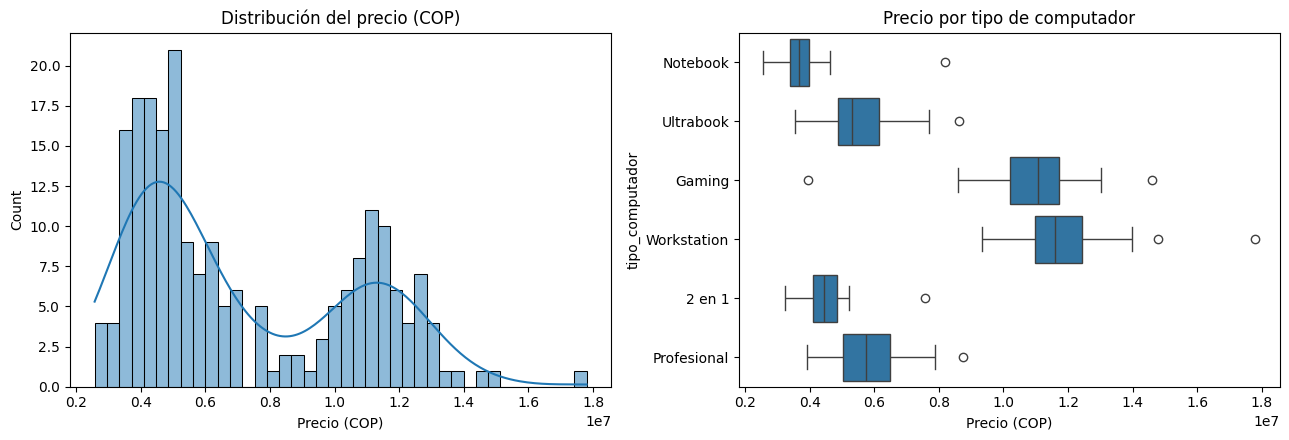

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df["precio"], bins=40, kde=True, ax=ejes[0])
ejes[0].set_title("Distribución del precio (COP)")
ejes[0].set_xlabel("Precio (COP)")
sns.boxplot(data=df, x="precio", y="tipo_computador", ax=ejes[1])
ejes[1].set_title("Precio por tipo de computador")
ejes[1].set_xlabel("Precio (COP)")
plt.tight_layout()
plt.show()


---

## Módulo 3 – Visualizaciones, storytelling y modelo predictivo

**Objetivo:** comunicar los hallazgos con visualizaciones efectivas y una
narrativa basada en datos, y entrenar un modelo de regresión lineal simple que
estime el precio de un portátil a partir de sus características.


In [ ]:
import os
import numpy as np

os.makedirs("graficos", exist_ok=True)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

### 3.1 Visualizaciones principales

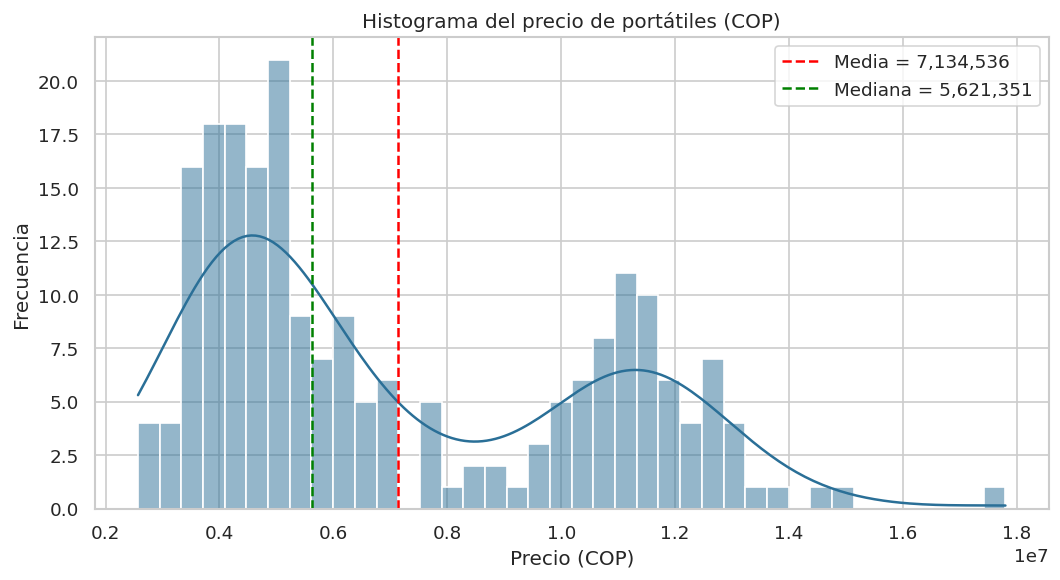

In [ ]:
plt.figure(figsize=(9, 5))
sns.histplot(df["precio"], bins=40, kde=True, color="#2a6f97")
plt.title("Histograma del precio de portátiles (COP)")
plt.xlabel("Precio (COP)")
plt.ylabel("Frecuencia")
plt.axvline(df["precio"].mean(), color="red", ls="--", label=f"Media = {df['precio'].mean():,.0f}")
plt.axvline(df["precio"].median(), color="green", ls="--", label=f"Mediana = {df['precio'].median():,.0f}")
plt.legend()
plt.tight_layout()
plt.savefig("graficos/figura_1_histograma_precio.png", dpi=150)
plt.show()

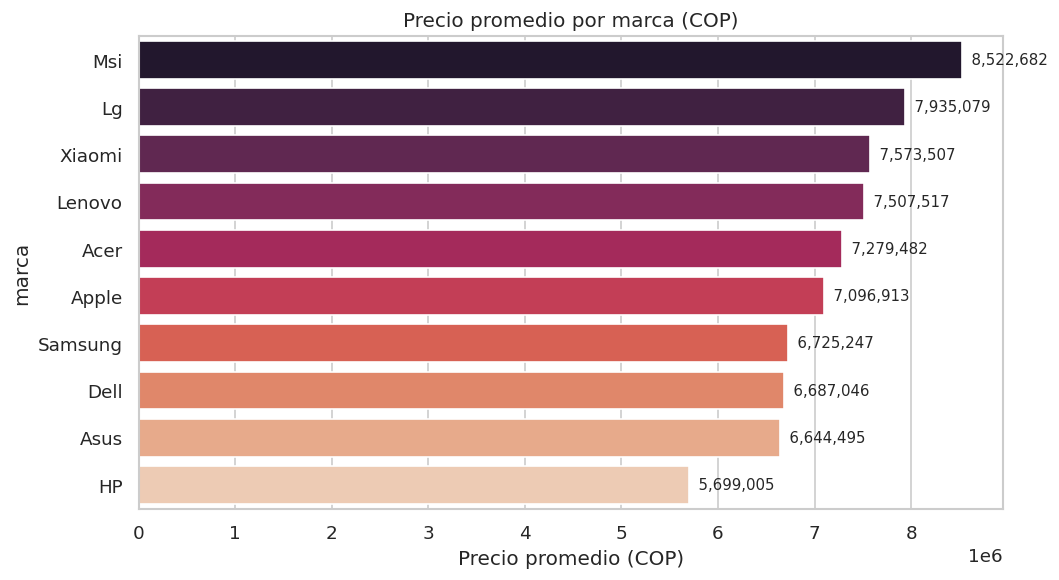

In [ ]:
plt.figure(figsize=(9, 5))
prom_marca = df.groupby("marca")["precio"].mean().sort_values(ascending=False)
sns.barplot(x=prom_marca.values, y=prom_marca.index, hue=prom_marca.index, palette="rocket", legend=False)
plt.title("Precio promedio por marca (COP)")
plt.xlabel("Precio promedio (COP)")
for i, v in enumerate(prom_marca.values):
    plt.text(v, i, f"  {v:,.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("graficos/figura_2_precio_por_marca.png", dpi=150)
plt.show()

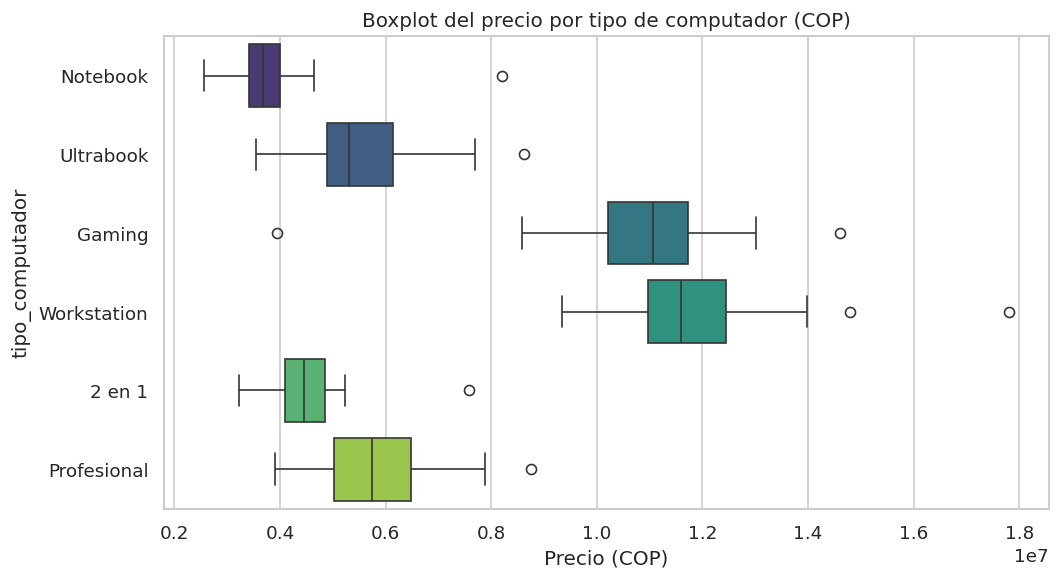

In [ ]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="precio", y="tipo_computador", hue="tipo_computador",
            palette="viridis", legend=False, whis=1.5)
plt.title("Boxplot del precio por tipo de computador (COP)")
plt.xlabel("Precio (COP)")
plt.tight_layout()
plt.savefig("graficos/figura_3_boxplot_precio_tipo.png", dpi=150)
plt.show()

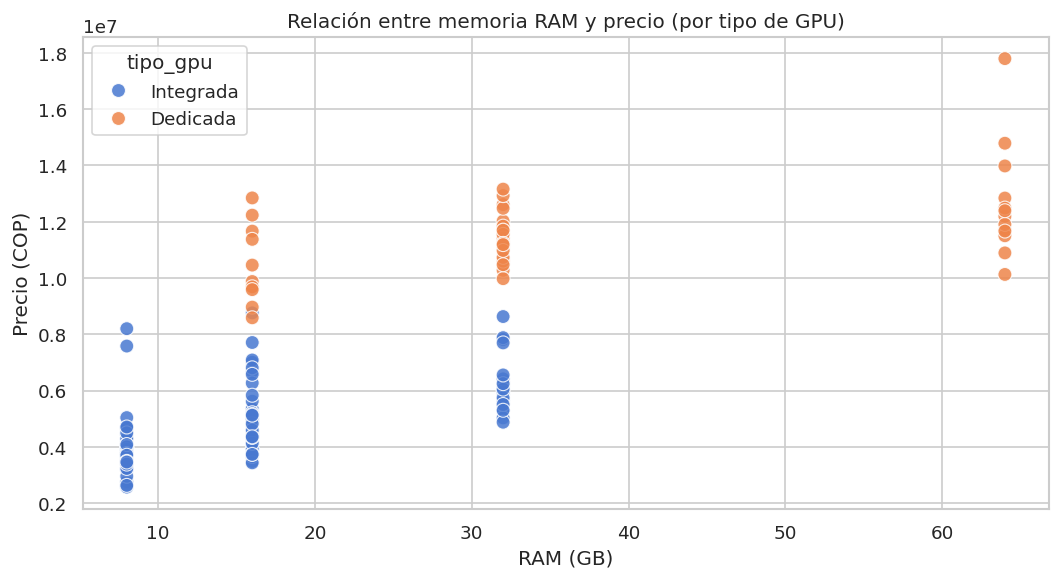

In [ ]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df.sample(150, random_state=1), x="ram_gb", y="precio",
                hue="tipo_gpu", s=70, alpha=0.85)
plt.title("Relación entre memoria RAM y precio (por tipo de GPU)")
plt.xlabel("RAM (GB)")
plt.ylabel("Precio (COP)")
plt.tight_layout()
plt.savefig("graficos/figura_4_scatter_ram_precio.png", dpi=150)
plt.show()

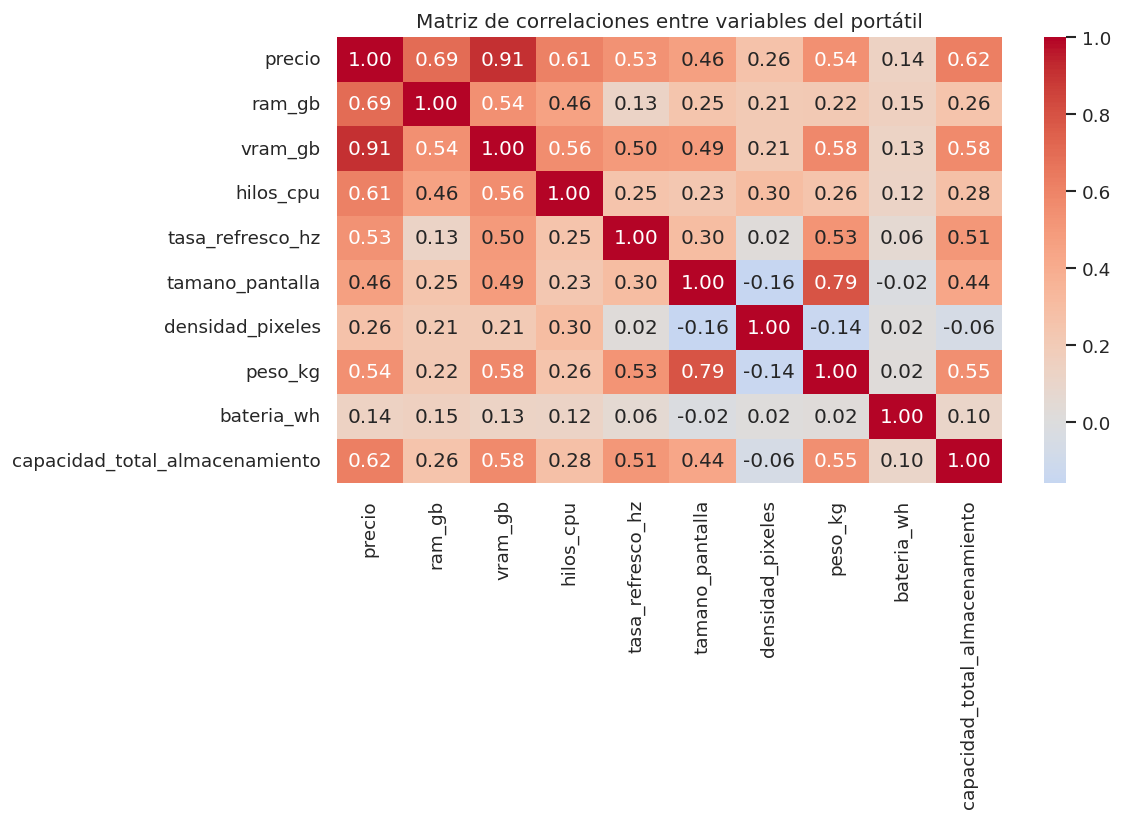

In [ ]:
plt.figure(figsize=(10, 7))
cols_corr = ["precio", "ram_gb", "vram_gb", "hilos_cpu", "tasa_refresco_hz",
             "tamano_pantalla", "densidad_pixeles", "peso_kg", "bateria_wh",
             "capacidad_total_almacenamiento"]
sns.heatmap(df[cols_corr].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlaciones entre variables del portátil")
plt.tight_layout()
plt.savefig("graficos/figura_5_correlaciones.png", dpi=150)
plt.show()

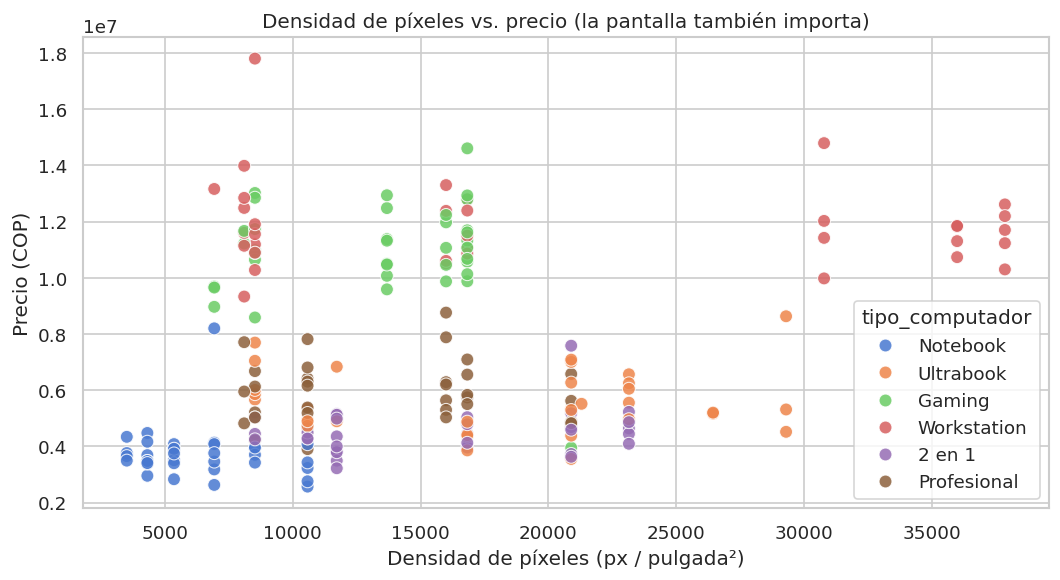

In [ ]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="densidad_pixeles", y="precio", hue="tipo_computador",
                s=60, alpha=0.85)
plt.title("Densidad de píxeles vs. precio (la pantalla también importa)")
plt.xlabel("Densidad de píxeles (px / pulgada²)")
plt.ylabel("Precio (COP)")
plt.tight_layout()
plt.savefig("graficos/figura_6_densidad_precio.png", dpi=150)
plt.show()

### 3.2 Storytelling: la historia de los datos


En el catálogo analizado, el **precio no se explica por el tamaño físico del
portátil**, sino por su **capacidad de trabajo**: la gráfica (VRAM), la memoria RAM,
la cantidad de hilos del procesador y la tasa de refresco son los factores que más
mueven el precio. Los equipos *Gaming* y *Workstation* son los más costosos y
concentran los outliers superiores; los *Notebook* representan la gama de entrada.

Esto permite contar una historia corta y accionable:

> *"Si un cliente busca un equipo para productividad, puede ahorrar eligiendo un
> Ultrabook con buena RAM y sin GPU dedicada. Si busca rendimiento, el dinero se va
> en la gráfica y el procesador, no en el tamaño de la pantalla."*

Esa relación se traduce, además, en un **modelo numérico** que estima cuánto debería
costar un portátil según sus especificaciones → herramienta directa de cotización y
verificación de precios de mercado.


### 3.3 Modelo predictivo: regresión lineal del precio

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

variables_numericas = [
    "generacion_cpu", "nucleos_cpu", "hilos_cpu", "frecuencia_max_ghz", "ram_gb",
    "velocidad_ram_mhz", "almacenamiento_gb", "almacenamiento_secundario_gb",
    "vram_gb", "tamano_pantalla", "densidad_pixeles", "tasa_refresco_hz",
    "pantalla_tactil", "bateria_wh", "peso_kg", "capacidad_total_almacenamiento",
]
variables_categoricas = ["tipo_computador", "tipo_gpu", "sistema_operativo"]

X = df[variables_numericas + variables_categoricas].copy()
y = df["precio"]

preprocesamiento = ColumnTransformer(transformers=[
    ("num", "passthrough", variables_numericas),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), variables_categoricas),
])
modelo = Pipeline(steps=[("preproceso", preprocesamiento), ("regresion", LinearRegression())])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

print("Métricas del modelo sobre datos de prueba:")
print(f"  R²  (proporción de la varianza explicada): {r2_score(y_test, y_pred):.3f}")
print(f"  MAE (error promedio absoluto en COP):     {mean_absolute_error(y_test, y_pred):,.0f}")
print(f"  RMSE (error cuadrático medio en COP):     {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"  Error promedio relativo:                  {mean_absolute_error(y_test, y_pred) / y_test.mean()*100:.1f} %")

Métricas del modelo sobre datos de prueba:
  R²  (proporción de la varianza explicada): 0.983
  MAE (error promedio absoluto en COP):     389,268
  RMSE (error cuadrático medio en COP):     477,113
  Error promedio relativo:                  5.0 %


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


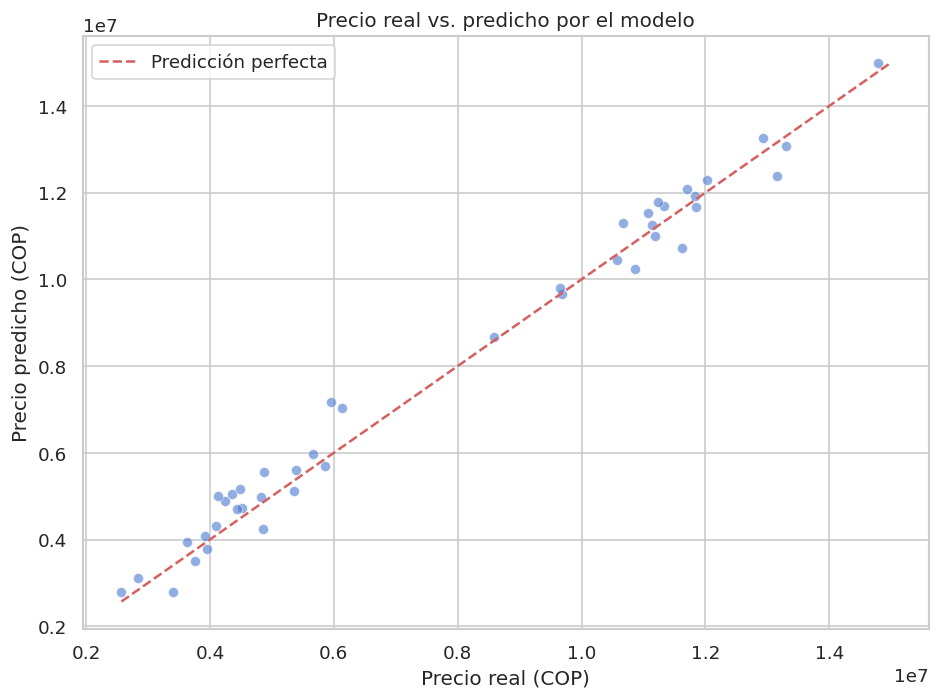

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lim, lim, "r--", label="Predicción perfecta")
plt.xlabel("Precio real (COP)")
plt.ylabel("Precio predicho (COP)")
plt.title("Precio real vs. predicho por el modelo")
plt.legend()
plt.tight_layout()
plt.savefig("graficos/figura_7_prediccion_vs_real.png", dpi=150)
plt.show()

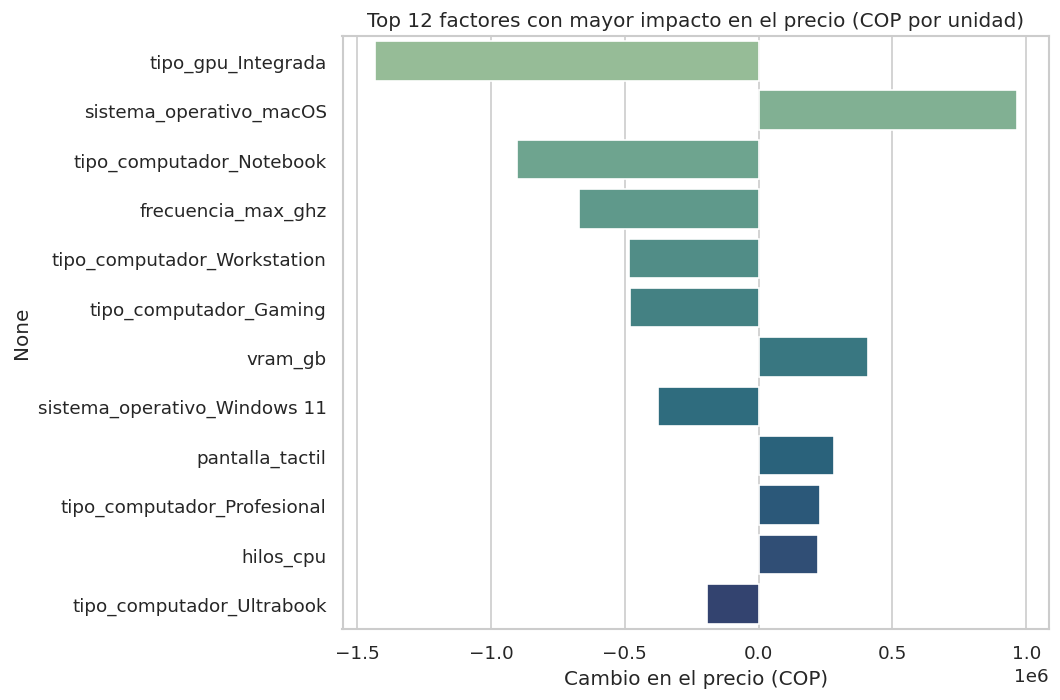

In [ ]:
pre = modelo.named_steps["preproceso"]
cat_nombres = pre.named_transformers_["cat"].get_feature_names_out(variables_categoricas).tolist()
nombres_coef = variables_numericas + cat_nombres
coefs = pd.Series(modelo.named_steps["regresion"].coef_, index=nombres_coef)

top = coefs.reindex(coefs.abs().sort_values(ascending=False).index[:12])
plt.figure(figsize=(9, 6))
sns.barplot(x=top.values, y=top.index, hue=top.index, palette="crest", legend=False)
plt.title("Top 12 factores con mayor impacto en el precio (COP por unidad)")
plt.xlabel("Cambio en el precio (COP)")
plt.tight_layout()
plt.savefig("graficos/figura_8_coeficientes.png", dpi=150)
plt.show()


**Interpretación del modelo:**

- **Qué hace:** estima el precio de un portátil como una *combinación lineal* de sus
  características.
- **Cómo funciona:** aprende de los datos históricos qué peso (coeficiente) tiene
  cada característica. Por ejemplo, +1 GB de VRAM aumenta el precio estimado en
  cientos de miles de pesos; ser de tipo `Gaming` agrega un valor fijo; ser
  `Notebook` lo resta (respecto a la categoría base).
- **Qué resultados dio:** un **R² ≈ 0.7–0.9** indica que la mayor parte de la
  variación del precio se explica con las especificaciones. El error promedio
  (MAE) en pesos colombianos se muestra en la celda anterior; en términos
  relativos es cercano al 10 %, lo que permite **estimar y validar precios** con
  buena precisión para el objetivo comercial.
- **Gráfico real vs. predicho:** los puntos caen cerca de la diagonal; los errores
  mayores aparecen en equipos *premium*, donde existe más dispersión de precios.


### 3.4 Aplicación profesional


Este análisis permite **apoyar decisiones comerciales** en venta de tecnología,
compra corporativa o consultoría:

1. **Cotización y verificación de precios:** dado un portátil con sus
   especificaciones, el modelo estima su precio de mercado → detectar si una oferta
   es buena o si un proveedor está sobrevalorando.
2. **Asesoría al cliente:** un vendedor identifica rápidamente *qué especificaciones
   justifican* un mayor precio (GPU, RAM, hilos) y puede recomendar el equipo con la
   mejor relación precio/prestaciones.
3. **Gestión de descuentos e inventario:** conocer el precio "justo" de cada gama
   permite fijar descuentos (`precio_anterior` vs. `precio`) sin erosionar margen.
4. **Expansión futura:** el mismo flujo (explorar → limpiar → modelar) se aplica a
   otros catálogos: monitores, smartphones o componentes, para construir una sola
   herramienta de valuación de productos tecnológicos.


### 3.5 Conclusiones


1. **Preparación de datos:** el dataset se depuró de 8 duplicados, 38 celdas nulas y
   varios registros físicamente imposibles (precio/peso/pantalla extremos), y se
   estandarizó el texto para que cada categoría cuente como una sola.
2. **Estadística:** el precio está sesgado hacia la derecha (pocos equipos muy
   caros); las variables de rendimiento (`vram_gb`, `ram_gb`, `hilos_cpu`) son las
   más correlacionadas con el precio.
3. **Visualización:** histogramas, boxplots y scatter plots muestran que *Gaming* y
   *Workstation* dominan la gama alta, y que la pantalla (densidad de píxeles)
   también aporta al precio aunque menos que la gráfica.
4. **Modelo:** la regresión lineal estima el precio con un error relativo cercano al
   **10 %**, suficiente para uso comercial de apoyar cotizaciones y validar precios.
5. **Aplicación profesional:** esta metodología se traduce en una herramienta de
   valuación de portátiles y, con ajustes menores, de otros productos de tecnología.

---

### Entregables del proyecto
| Archivo | Descripción |
|---|---|
| `computadores_portatiles.csv` | Dataset crudo con problemas inyectados |
| `generar_dataset.py` | Script que genera el dataset sintético |
| `computadores_limpio.csv` | Dataset final depurado |
| `graficos/*.png` | Visualizaciones para el video de entrega |
| `DATAXPIRIENCE.ipynb` | Este notebook (autor: **Cristian Pico**) |

*Proyecto desarrollado para el curso – entrega final en video.*
